In [7]:
import os
os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')
import geopandas as gpd
import configparser
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
from cmap import Colormap

from core.swot_project import SwotProject
from core.plot_raster import PlotRaster

main_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre"

# Plotting for Porto Alegre

This notebook uses the rasters generated before to plot the results of the PortoAlegre exercise. The rasters are stored in the `rasters` folder and the plots are stored in the `plots` folder.

First, we need to load the project:

In [8]:
config = configparser.ConfigParser()
config.read(main_path + '/config.cfg')

swot_project = SwotProject(config)
# print(swot_project)

No automatic download, please use the Downloader object to download the data


In [13]:
swot_project.find_raster()
# print(swot_project.rasters_list)


Then, once loaded, we need to create, load and pre-treat the SWOT data used for plotting.
Here we use the collection object within the project to create a new collection with the dry and flooded times selected.

In [10]:
# swot_project.Rasterizer.gdalwarp_raster_to_swot_bbox_and_size(
#     Path('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/ESA_WorldCover_10m_merged_32722_clip.tif'),
#     32722,
#     "near"
# )

In [14]:
# takes around 2 minutes for 5 raster files of 1.65Go
swot_project.create_collection()
# swot_project.floodmask

Opening SWOT raster at time: 2024-05-06 11:46:43
Opening SWOT raster at time: 2024-03-04 21:31:21
Dimension x of data1: 8052 and dimension x of data2: 7029


ValueError: [GLOBAL MASK] The shape of the SWOT Raster and the World Cover data are not the same

We can then create the plot object that we will use to plot the data.

In [ ]:
plot_obj = PlotRaster(
    swot_project,
    save_fig=True,
    show_fig=True
    )

Finally, we can plot the data using the plot object.

Below, a function to plot the control area and histograms associated with the control area.

# Gamma tot

In [ ]:
# plot_obj.plot_control_maps_and_histograms(
#     'gamma_tot', 
#     time_selection="2024-05-06",
#     cmap=Colormap("seaborn:mako").to_matplotlib(),
#     y_label="Porto Alegre, Rio Grande do Sul\nEMSN 192",
#     vmin=0,
#     vmax=1,
#     )


Plot mean histograms with the dates that compose the mean.

In [ ]:
# fig,ax = plot_obj.plot_mean_hist_computation(
#     'gamma_tot',
#     hist_range=(0,1),
#     add_legend=False
# )

Below, the function to plot a map.

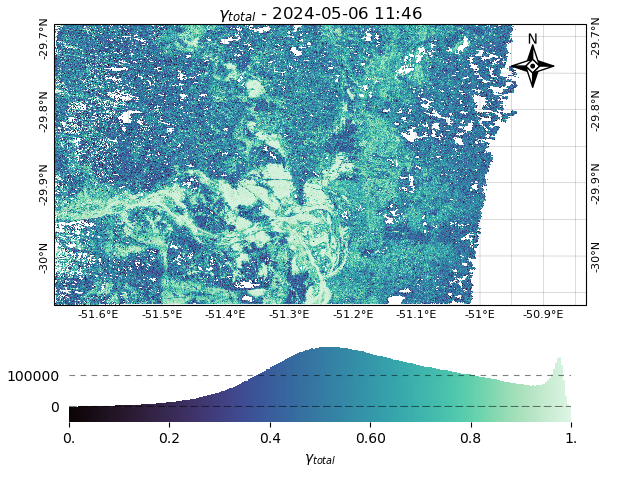

In [10]:
# takes around 1 minute
fig, ax = plot_obj.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2024-05-06",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False
    )

Below a function to plot an histogram.

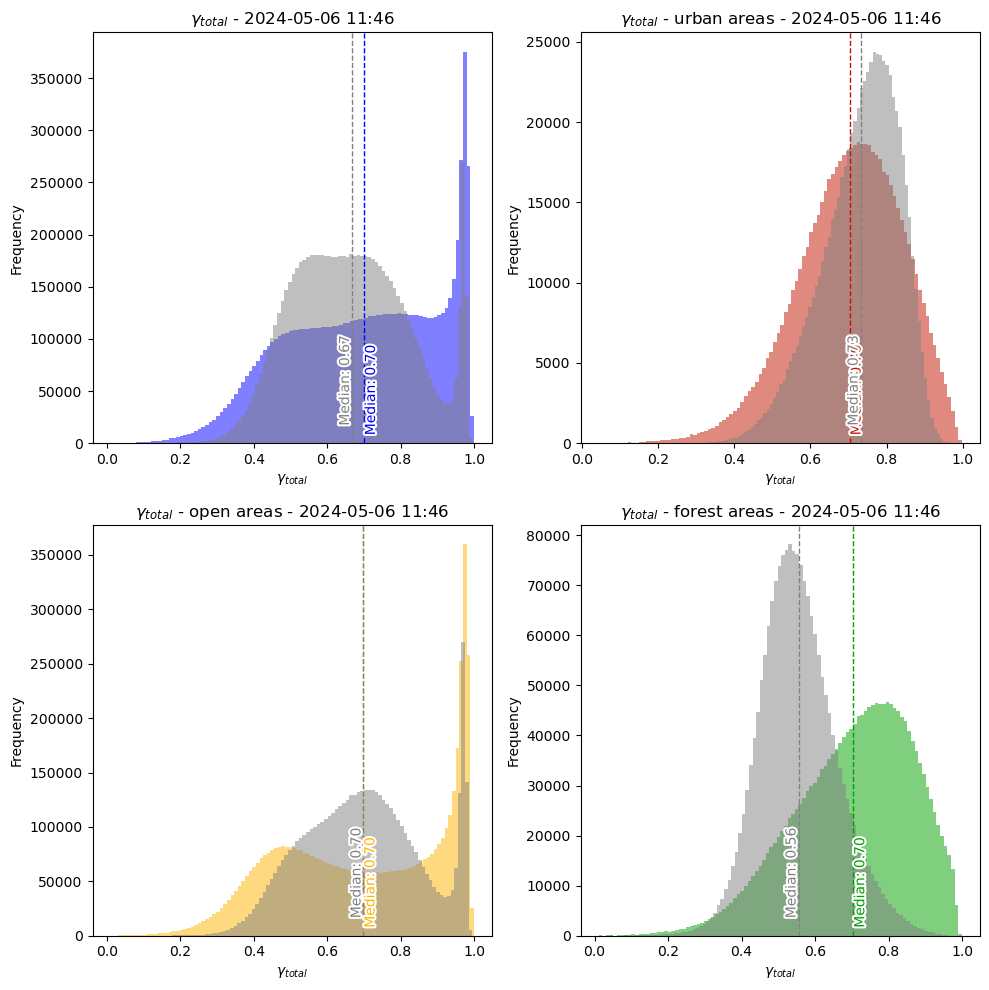

In [7]:
# takes around 1 minute for seaborn method, 15s for matplotlib method
fig, ax = plt.subplots(2,2, figsize=(10, 10))

fig, ax[0,0] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2024-05-06",
    use_seaborn=False,
    fig=fig,
    ax=ax[0,0],
    save_fig=False,
    show_fig=False,
    )
fig, ax[0,1] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection='urban',
    time_selection="2024-05-06",
    use_seaborn=False,
    fig=fig,
    ax=ax[0,1],
    save_fig=False,
    show_fig=False,
    )
fig, ax[1,0] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection='open',
    time_selection="2024-05-06",
    use_seaborn=False,
    fig=fig,
    ax=ax[1,0],
    save_fig=False,
    show_fig=False,
    )
fig, ax[1,1] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection='forest',
    time_selection="2024-05-06",
    use_seaborn=False,
    fig=fig,
    ax=ax[1,1],
    save_fig=False,
    show_fig=False,
    )

fig.tight_layout()
fig.show()

And then, the function to combine maps and histograms.

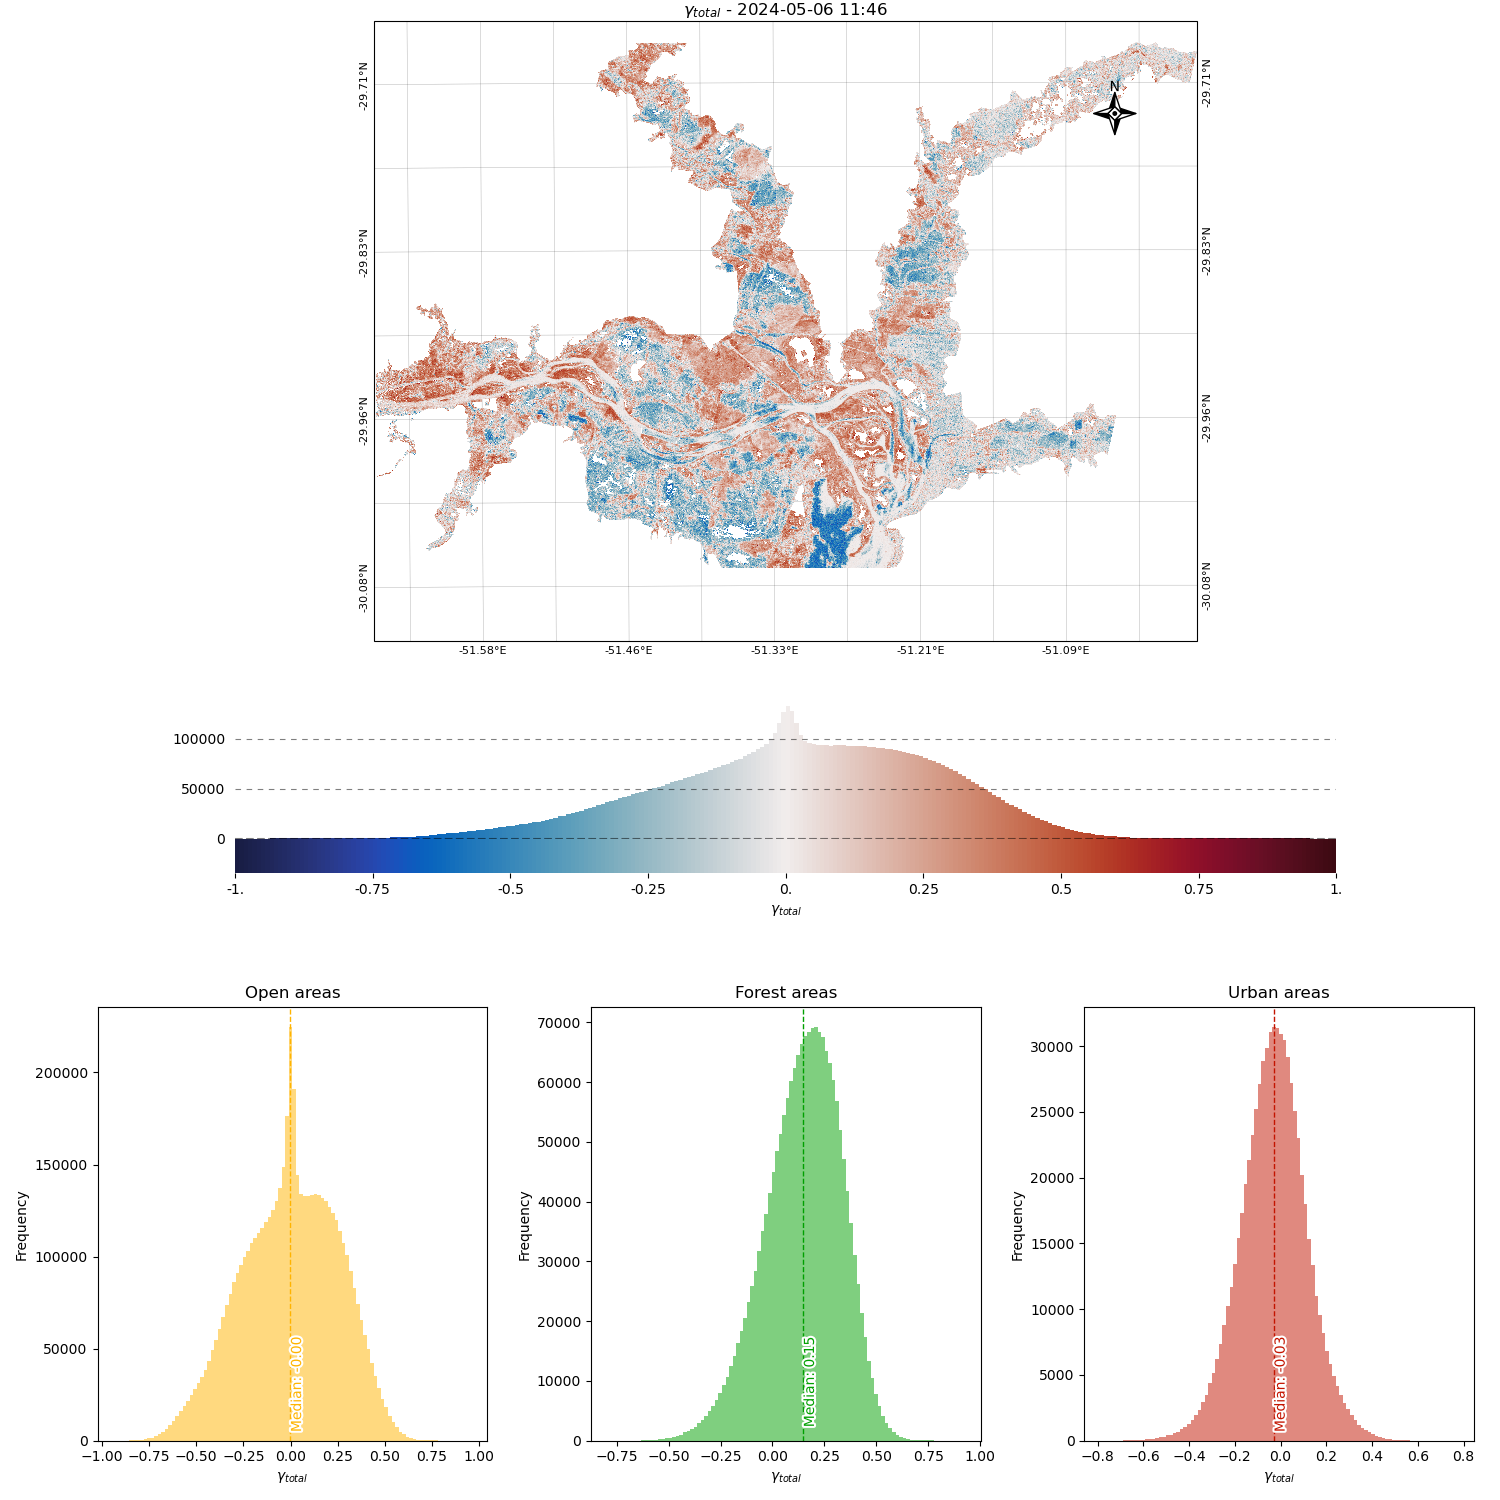

In [8]:
# takes around 1 minute 15s for matplotlib method, 4 minutes for seaborn method
fig, ax = plot_obj.plot_map_with_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="diff",
    # world_cover_mask=['urban'],
    time_selection="2024-05-06",
    vmin=-1,
    vmax=1,
    add_bkg=False,
    # cmap=Colormap("seaborn:mako").to_matplotlib(),
    cmap=Colormap("cmocean:balance").to_matplotlib(),
    use_seaborn=False
    )

In [ ]:
# from skimage.filters import rank
# from skimage.morphology import disk
# import numpy as np

# footprint = disk(2)

# # data = plot_obj.swot_collection.swot_flood_rasters_flood.gamma_tot.values[0]
# data = plot_obj.swot_collection.swot_mean.gamma_tot.values
# cv = data > 0.8
# # norm between 0 and 255
# data = data * 255
# mask = data == np.nan
# data[mask] = 0

# majority_filt = rank.majority(data.astype(np.uint8), footprint=footprint, mask=~mask)
# grad = rank.gradient(data.astype(np.uint8), footprint=footprint, mask=~mask)
# entropy = rank.entropy(data.astype(np.uint8), footprint=footprint, mask=~mask)

# fig, ax = plt.subplots(2,2, figsize=(20, 20))

# im = ax[0,0].imshow(data, cmap=Colormap("seaborn:mako").to_matplotlib())
# plt.colorbar(im, ax=ax[0,0])
# ax[0,0].set_title('Original image')

# im = ax[0,1].imshow(majority_filt, cmap=Colormap("seaborn:mako").to_matplotlib())
# plt.colorbar(im, ax=ax[0,1])
# ax[0,1].set_title('Majority filter')

# im = ax[1,1].imshow(grad, cmap='cividis')
# plt.colorbar(im, ax=ax[1,1])
# ax[1,1].set_title('Gradient')

# im = ax[1,0].imshow(entropy, cmap='magma')
# plt.colorbar(im, ax=ax[1,0])
# ax[1,0].set_title('Entropy')

# plt.show()

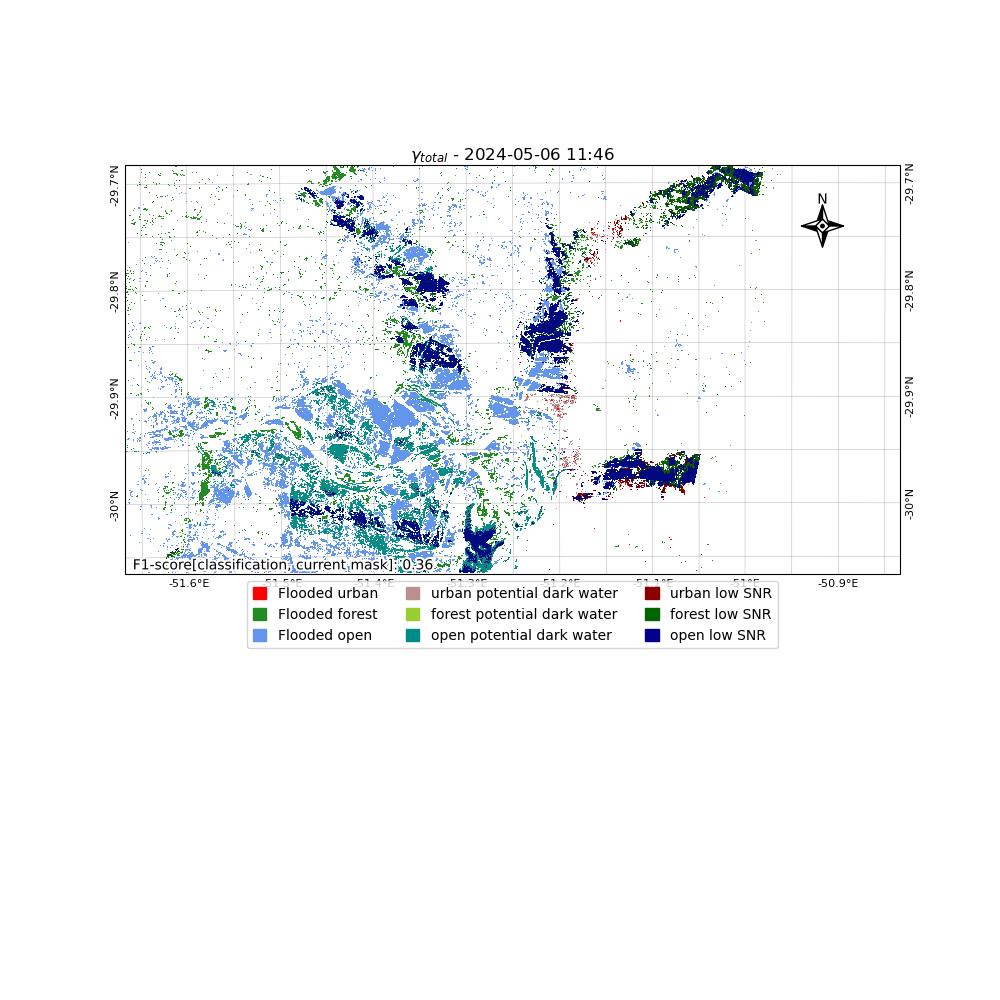

In [10]:
# takes around 5 minutes
fig, ax = plot_obj.plot_map_mask(
    variable="gamma_tot", 
    data_area="global", #global or flood or control
    data_type="diff", #diff or swot or mean (not working well for mean)
    # data_type="swot", #swot
    time_selection="2024-05-06",
    thresholds={"urban":-0.1, "forest":0.1, "open":0.1}, #diff
    # thresholds={"urban":-0., "forest":0.7, "open":0.8}, #swot
    # thresholds={"urban":-0.1, "forest":0.65, "open":0.8}, # swot with urban diff
    urban_diff=True,
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    threshold_gamma=-0.15, #diff
    # threshold_gamma=0.5, #swot
    add_bkg=False,
    add_legend=True,
    disk_size=3
    )